# #30DayMapChallenge - Día 9: AI Generated
## Caso de Negocio: Clasificar el suelo desde el espacio (y decidir con ML)

**Autor:** Mario Ignacio Ibañez Castro | **Rol:** Data Scientist & Strategic Planner

### El objetivo
Pasamos de vectores y DEM a **inteligencia artificial sobre satélite**: un Random Forest que clasifica cada píxel Sentinel-2 en uso de suelo (vegetación, urbano, suelo desnudo, agua).

**Pregunta de negocio:** ¿Cuánto del área de interés es construido vs verde — y dónde quedan bolsas de suelo “blando” para expansión o riesgo?

**Reto técnico:** Modelo de ML para clasificación/segmentación de imagen satelital.

**Fuente:** Sentinel-2 L2A (Earth Search / AWS COGs) — escena `S2B_14QMG_20240326` sobre CDMX.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import rasterio
from rasterio.plot import reshape_as_image
from rasterio.warp import calculate_default_transform, reproject, Resampling
from pathlib import Path
import contextily as ctx
from matplotlib.colors import ListedColormap, BoundaryNorm

plt.style.use('dark_background')
%matplotlib inline

RUTA = Path('../00_Datos')
OUT = Path('.')
S2 = RUTA / 'sentinel2_cdmx_subset.tif'
CLASS = RUTA / 'landcover_rf_cdmx.tif'
CONF = RUTA / 'landcover_rf_confianza.tif'
METRICS = RUTA / 'rf_metrics.json'

CLASES = {1: 'Vegetación', 2: 'Urbano', 3: 'Suelo desnudo', 4: 'Agua'}
COLORS = ['#2ECC71', '#E74C3C', '#F5CBA7', '#3498DB']
cmap = ListedColormap(COLORS)
norm = BoundaryNorm([0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

### 1. Sentinel-2: composición RGB y NDVI
Primero vemos la evidencia cruda: color natural + índice de vegetación.

/tmp/ipykernel_243293/4244167190.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  blue = src.read(1).astype('float32') / 10000
/tmp/ipykernel_243293/4244167190.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  green = src.read(2).astype('float32') / 10000
/tmp/ipykernel_243293/4244167190.py:4: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  red = src.read(3).astype('float32') / 10000
/tmp/ipykernel_243293/4244167190.py:5: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=F

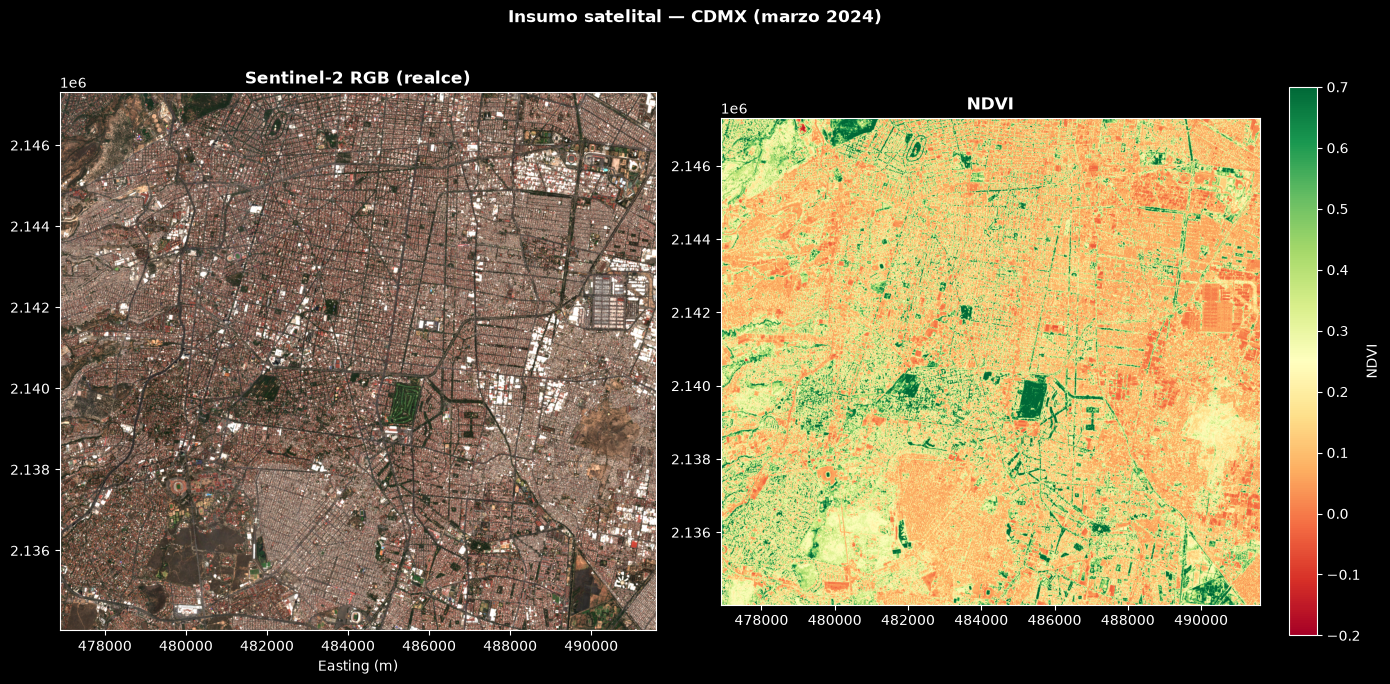

Guardado: Dia9_Sentinel_RGB_NDVI.png


In [2]:
with rasterio.open(S2) as src:
    blue = src.read(1).astype('float32') / 10000
    green = src.read(2).astype('float32') / 10000
    red = src.read(3).astype('float32') / 10000
    nir = src.read(4).astype('float32') / 10000
    transform = src.transform
    crs = src.crs
    bounds = src.bounds

ndvi = (nir - red) / (nir + red + 1e-6)
rgb = np.dstack([
    np.clip(red * 3.5, 0, 1),
    np.clip(green * 3.5, 0, 1),
    np.clip(blue * 3.5, 0, 1),
])

extent = [bounds.left, bounds.right, bounds.bottom, bounds.top]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
fig.patch.set_facecolor('black')
axes[0].imshow(rgb, extent=extent, origin='upper')
axes[0].set_title('Sentinel-2 RGB (realce)', fontweight='bold', color='white')
axes[0].set_xlabel('Easting (m)'); axes[0].tick_params(colors='white')
im = axes[1].imshow(ndvi, extent=extent, origin='upper', cmap='RdYlGn', vmin=-0.2, vmax=0.7)
axes[1].set_title('NDVI', fontweight='bold', color='white')
axes[1].tick_params(colors='white')
cb = plt.colorbar(im, ax=axes[1], fraction=0.046)
cb.set_label('NDVI', color='white'); cb.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')
for ax in axes:
    ax.tick_params(colors='white')
fig.suptitle('Insumo satelital — CDMX (marzo 2024)', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'Dia9_Sentinel_RGB_NDVI.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia9_Sentinel_RGB_NDVI.png')

### 2. El modelo: Random Forest pixel-wise
Pipeline (`clasificarUsoSuelo.py`):

1. Features: Blue, Green, Red, NIR, NDVI, NDWI, brillo
2. Etiquetas semilla por reglas espectrales (agua / vegetación / urbano / suelo)
3. Muestreo estratificado → train/test
4. `RandomForestClassifier` predice **todo el raster**

Es “AI generated” en el sentido operativo: el mapa de clases lo produce el modelo, no un digitalizador humano.

Accuracy (test): 0.999
Train/Test: 9,442 / 3,148

Importancia de features:
  ndvi         0.277
  ndwi         0.237
  brightness   0.154
  nir          0.125
  red          0.092
  green        0.066
  blue         0.049


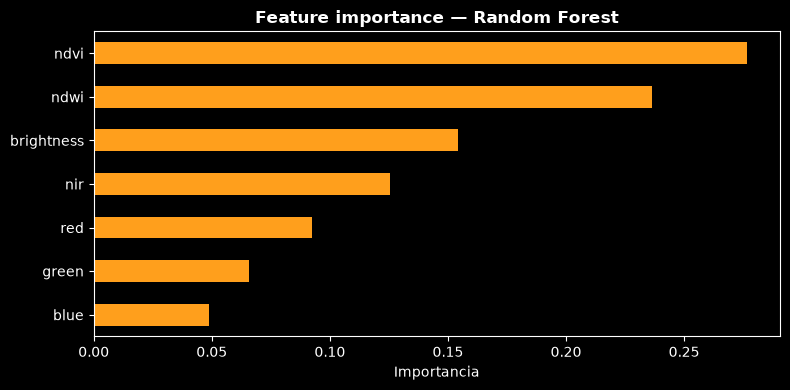

In [3]:
metrics = json.loads(METRICS.read_text())
print(f"Accuracy (test): {metrics['accuracy']:.3f}")
print(f"Train/Test: {metrics['n_train']:,} / {metrics['n_test']:,}")
print('\nImportancia de features:')
for k, v in sorted(metrics['feature_importances'].items(), key=lambda x: -x[1]):
    print(f'  {k:12s} {v:.3f}')

imp = pd.Series(metrics['feature_importances']).sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
fig.patch.set_facecolor('black'); ax.set_facecolor('black')
imp.plot(kind='barh', color='#FF9F1C', ax=ax)
ax.set_title('Feature importance — Random Forest', color='white', fontweight='bold')
ax.tick_params(colors='white')
ax.set_xlabel('Importancia', color='white')
plt.tight_layout()
plt.savefig(OUT / 'Dia9_Feature_Importance.png', dpi=140, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 3. Mapa clasificado + simbología
Cada color = una decisión del modelo.

/tmp/ipykernel_243293/1928729224.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  pred = src.read(1)


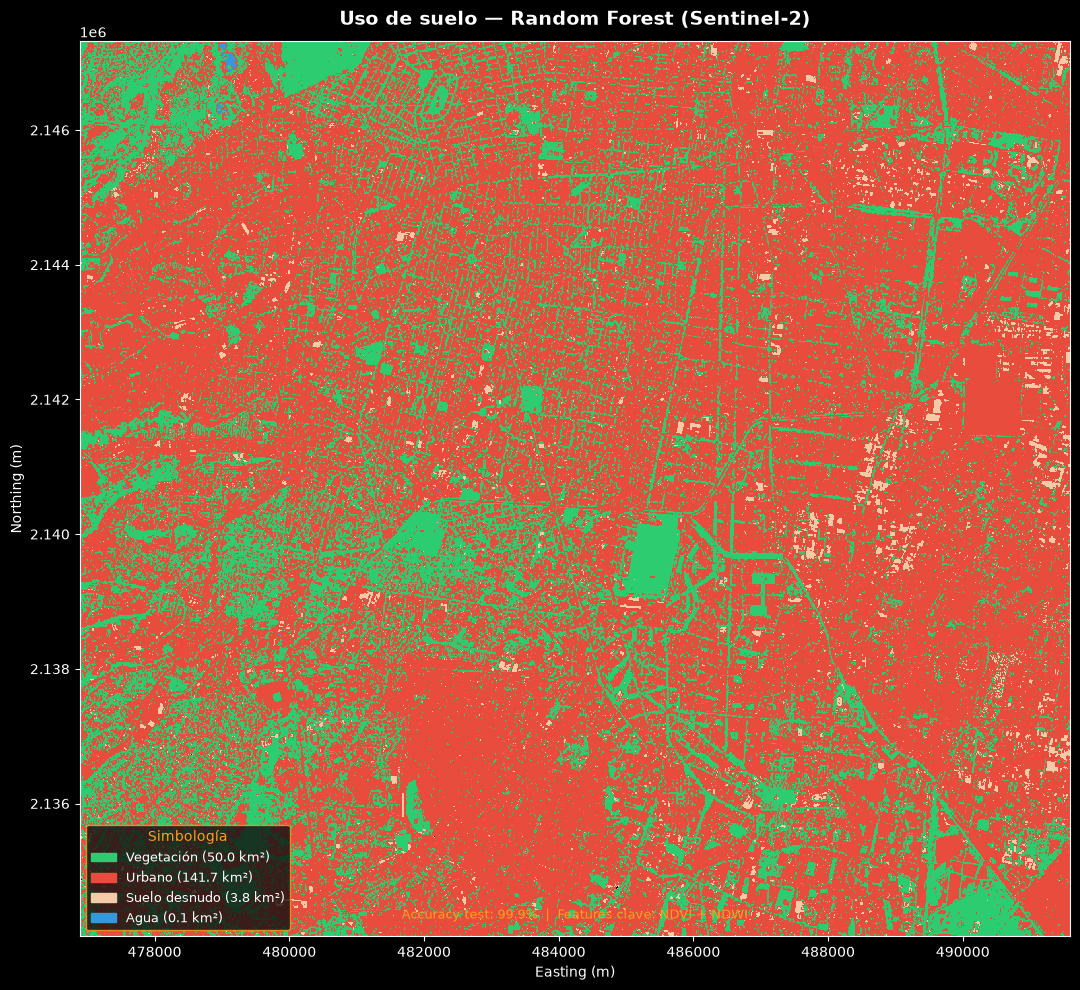

Áreas: {'Vegetación': 49.9606, 'Urbano': 141.6542, 'Suelo desnudo': 3.8066, 'Agua': 0.0729}
Guardado: Dia9_Landcover_RF.png


In [4]:
with rasterio.open(CLASS) as src:
    pred = src.read(1)
    bounds_c = src.bounds
    transform_c = src.transform
    crs_c = src.crs

extent_c = [bounds_c.left, bounds_c.right, bounds_c.bottom, bounds_c.top]
pixel_km2 = abs(transform_c.a * transform_c.e) / 1e6
areas = {CLASES[c]: float((pred == c).sum() * pixel_km2) for c in CLASES}

fig, ax = plt.subplots(figsize=(11, 10))
fig.patch.set_facecolor('black')
im = ax.imshow(np.ma.masked_equal(pred, 0), extent=extent_c, origin='upper', cmap=cmap, norm=norm, interpolation='nearest')
ax.set_title('Uso de suelo — Random Forest (Sentinel-2)', fontsize=14, fontweight='bold', color='white', pad=12)
ax.tick_params(colors='white')
ax.set_xlabel('Easting (m)', color='white'); ax.set_ylabel('Northing (m)', color='white')

patches = [
    mpatches.Patch(color=COLORS[i], label=f'{CLASES[c]} ({areas[CLASES[c]]:.1f} km²)')
    for i, c in enumerate(CLASES)
]
leg = ax.legend(handles=patches, loc='lower left', title='Simbología',
                facecolor='#111', edgecolor='#FF9F1C', labelcolor='white', fontsize=9, title_fontsize=10)
leg.get_title().set_color('#FF9F1C')

ax.text(0.5, 0.02, f"Accuracy test: {metrics['accuracy']:.1%}  |  Features clave: NDVI + NDWI",
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'Dia9_Landcover_RF.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Áreas:', areas)
print('Guardado: Dia9_Landcover_RF.png')

### 4. Confianza del modelo
La probabilidad máxima del RF por píxel: dónde el modelo duda (útil para auditoría).

/tmp/ipykernel_243293/1549416729.py:2: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  conf = src.read(1)


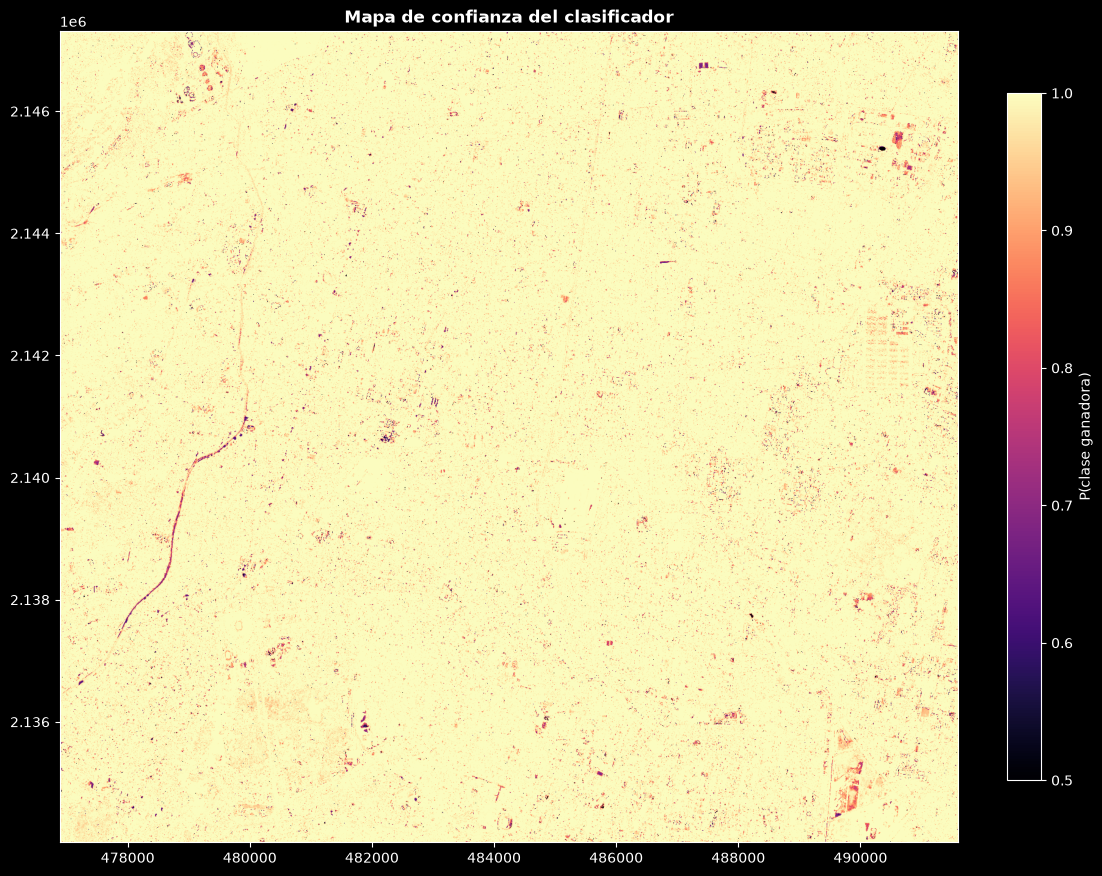

Confianza media: 0.991


In [5]:
with rasterio.open(CONF) as src:
    conf = src.read(1)
    conf = np.where(conf < 0, np.nan, conf)

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('black')
im = ax.imshow(conf, extent=extent_c, origin='upper', cmap='magma', vmin=0.5, vmax=1.0)
cb = plt.colorbar(im, ax=ax, fraction=0.035)
cb.set_label('P(clase ganadora)', color='white')
cb.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cb.ax.axes, 'yticklabels'), color='white')
ax.set_title('Mapa de confianza del clasificador', fontweight='bold', color='white')
ax.tick_params(colors='white')
plt.tight_layout()
plt.savefig(OUT / 'Dia9_Confianza.png', dpi=160, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print(f'Confianza media: {np.nanmean(conf):.3f}')

### 5. Overlay sobre basemap (contexto urbano)
Reproyectamos la clasificación a Web Mercator para contrastar con calles.

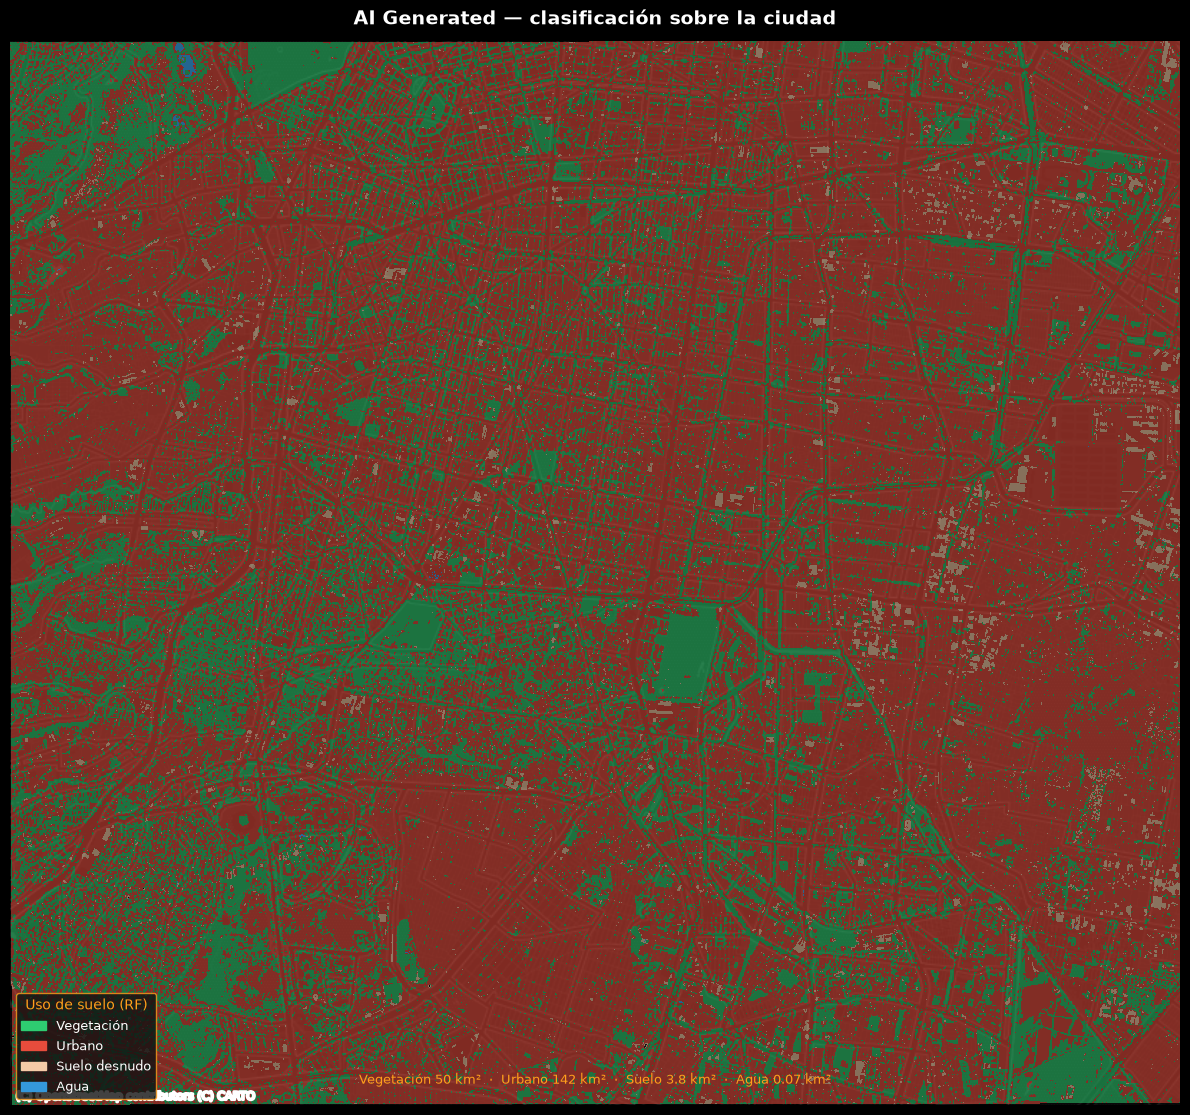

Guardado: Dia9_Landcover_Basemap.png


In [6]:
# Reproject class raster to 3857 for contextily
dst_crs = 'EPSG:3857'
with rasterio.open(CLASS) as src:
    t3857, w3857, h3857 = calculate_default_transform(src.crs, dst_crs, src.width, src.height, *src.bounds)
    pred3857 = np.empty((h3857, w3857), dtype=np.uint8)
    reproject(
        source=rasterio.band(src, 1),
        destination=pred3857,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=t3857,
        dst_crs=dst_crs,
        resampling=Resampling.nearest,
    )
    from rasterio.transform import array_bounds
    left, bottom, right, top = array_bounds(h3857, w3857, t3857)

# RGBA overlay
rgba = np.zeros((h3857, w3857, 4), dtype=np.float32)
color_map = {
    1: (0.18, 0.80, 0.44, 0.55),
    2: (0.91, 0.30, 0.24, 0.55),
    3: (0.96, 0.80, 0.65, 0.55),
    4: (0.20, 0.60, 0.86, 0.65),
}
for c, rgba_c in color_map.items():
    mask = pred3857 == c
    for i in range(4):
        rgba[:, :, i][mask] = rgba_c[i]

fig, ax = plt.subplots(figsize=(12, 12))
fig.patch.set_facecolor('black')
ax.set_xlim(left, right); ax.set_ylim(bottom, top)
try:
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.DarkMatterNoLabels, zoom_adjust=0, alpha=0.9, zorder=1)
except Exception as e:
    print(e)
ax.imshow(rgba, extent=[left, right, bottom, top], origin='upper', zorder=2, interpolation='nearest')

patches = [mpatches.Patch(color=COLORS[i], label=CLASES[c]) for i, c in enumerate(CLASES)]
leg = ax.legend(handles=patches, loc='lower left', title='Uso de suelo (RF)',
                facecolor='#111', edgecolor='#FF9F1C', labelcolor='white', fontsize=9, title_fontsize=10)
leg.get_title().set_color('#FF9F1C')
ax.set_axis_off()
ax.set_title('AI Generated — clasificación sobre la ciudad', fontsize=14, fontweight='bold', color='white', pad=12)
ax.text(0.5, 0.02,
        f"Vegetación {areas['Vegetación']:.0f} km²  ·  Urbano {areas['Urbano']:.0f} km²  ·  "
        f"Suelo {areas['Suelo desnudo']:.1f} km²  ·  Agua {areas['Agua']:.2f} km²",
        transform=ax.transAxes, ha='center', color='#FF9F1C', fontsize=9)
plt.tight_layout()
plt.savefig(OUT / 'Dia9_Landcover_Basemap.png', dpi=180, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()
print('Guardado: Dia9_Landcover_Basemap.png')

### 6. Panel resumen

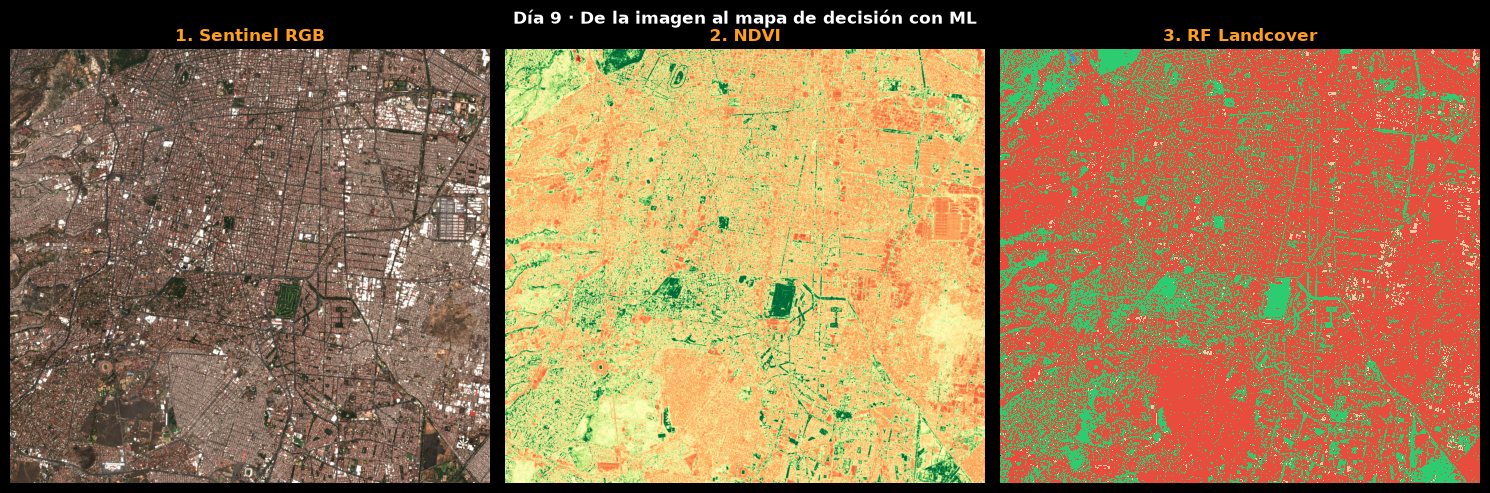

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('black')
axes[0].imshow(rgb, extent=extent, origin='upper')
axes[0].set_title('1. Sentinel RGB', color='#FF9F1C', fontweight='bold'); axes[0].set_axis_off()
axes[1].imshow(ndvi, extent=extent, origin='upper', cmap='RdYlGn', vmin=-0.2, vmax=0.7)
axes[1].set_title('2. NDVI', color='#FF9F1C', fontweight='bold'); axes[1].set_axis_off()
axes[2].imshow(np.ma.masked_equal(pred, 0), extent=extent_c, origin='upper', cmap=cmap, norm=norm, interpolation='nearest')
axes[2].set_title('3. RF Landcover', color='#FF9F1C', fontweight='bold'); axes[2].set_axis_off()
fig.suptitle('Día 9 · De la imagen al mapa de decisión con ML', color='white', fontweight='bold')
plt.tight_layout()
plt.savefig(OUT / 'Dia9_Panel.png', dpi=150, facecolor=fig.get_facecolor(), bbox_inches='tight')
plt.show()

### 7. Insight de negocio
- **~72% urbano** en el recorte ⇒ el suelo “fácil” ya está tomado.
- La vegetación remanente (~50 km² en el AOI) es activo climático y restricción de expansión.
- El ML no reemplaza el predio catastral: **prioriza** dónde mirar (verde vs construido vs suelo expuesto).

**Nota metodológica:** las etiquetas de entrenamiento nacen de reglas espectrales (semillas). El RF aprende una frontera más suave y produce el mapa completo + confianza. En producción se reemplazan semillas por muestras de campo / WorldCover.

### Regenerar
```bash
python ../00_Datos/descargarSentinel2.py
python ../00_Datos/clasificarUsoSuelo.py
```

In [8]:
print('Día 9 completado.')
print(f"Accuracy: {metrics['accuracy']:.3f}")
print(areas)

Día 9 completado.
Accuracy: 0.999
{'Vegetación': 49.9606, 'Urbano': 141.6542, 'Suelo desnudo': 3.8066, 'Agua': 0.0729}
